In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

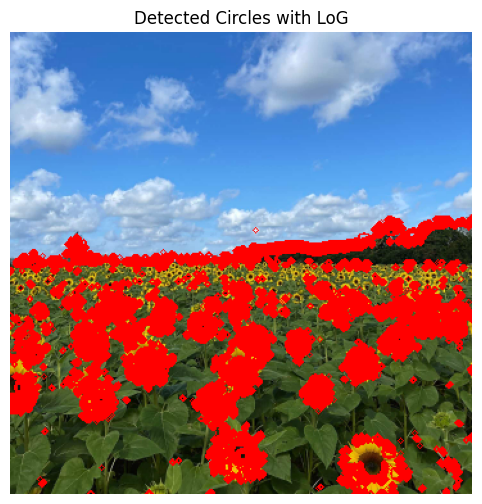

Largest detected circle -> Center: (105, 253), Radius: 8.49, Sigma used: 6.00
Sigma range used: [ 2  4  6  8 10 12 14 16 18]


In [33]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# Load image
im = cv.imread('C:/Users/User/Desktop/EN3160-Assignments/Assignment2/the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)

# Normalize
gray = gray.astype(np.float32) / 255.0

# Scale-space blob detection with LoG
sigmas = np.arange(2, 20, 2)   # [2, 4, 6, 8, 10, ..., 18]
h, w = gray.shape
response_stack = []

for sigma in sigmas:
    log = ndimage.gaussian_laplace(gray, sigma=sigma)
    response = (sigma**2) * (log**2)
    response_stack.append(response)

response_stack = np.stack(response_stack, axis=-1)

# Non-maximum suppression
coords = []
for i, sigma in enumerate(sigmas):
    max_resp = (response_stack[..., i] == response_stack.max(axis=-1))
    y, x = np.where(max_resp & (response_stack[..., i] > 0.003))
    for (xi, yi) in zip(x, y):
        coords.append((xi, yi, sigma*np.sqrt(2)))

# Draw circles
im_out = im.copy()
for x, y, r in coords:
    cv.circle(im_out, (int(x), int(y)), int(r), (0,0,255), 1)

plt.figure(figsize=(10, 6))
plt.imshow(cv.cvtColor(im_out, cv.COLOR_BGR2RGB))
plt.title("Detected Circles with LoG")
plt.axis("off")
plt.show()

largest_circle = max(coords, key=lambda c: c[2])
x, y, r = largest_circle
sigma_used = r / np.sqrt(2)
print(f"Largest detected circle -> Center: ({x}, {y}), Radius: {r:.2f}, Sigma used: {sigma_used:.2f}")
print("Sigma range used:", sigmas)


## Question: Line and Circle Fitting with RANSAC

In this problem, we will fit a **line** and subsequently a **circle** to a set of noisy points that conform to a line and a circle. The code snippet in **Listing 1** shows how to generate this noisy point set \(X\) that contains points forming both a circle and a line.  

- **Line parameterization:** A line can be characterized with three parameters \(a, b, d\) where \([a, b]^\top\) is the **unit normal** to the line and \(d\) is the perpendicular distance from the origin. (Refer to the slide on **Total Least Squares line fitting**.)  
- **Circle parameterization:** A circle can be described using the **center** \([x, y]^\top\) and the **radius** \(r\).  

Given a set of **inliers** (points that we know belong to a model, e.g., a circle), we can estimate the **best fitting model** using an optimizer like `scipy.minimize`. To learn about optimization, refer to section 1.1 of Boyd and Vandenberghe.  

We aim to find inliers within the framework of **RANSAC**. Consider the noisy point set \(X\).  

### Tasks

**(a)** Estimate the **line** using the **RANSAC algorithm** (must be coded on your own).  
- Apply the constraint \(\|[a,b]^\top\| = 1\).  
- Carefully select the **error metric** (normal distance to the estimated line) and the **minimum number of points** required for the consensus.  

**(b)** Subtract the consensus of the best line and estimate the **circle** that fits the remaining points using **RANSAC**.  
- Carefully select the **threshold of error** (radial error) and the **minimum number of points** required for the consensus.  

**(c)** Plot the results on the **same figure**:  
- The noisy point set \(X\)  
- The line estimated from the sample leading to the best estimate  
- The circle estimated from the sample leading to the best estimate  
- The sample of points used for estimation (e.g., three points for the circle)  
- The best-fit line and its inliers  
- The best-fit circle and its inliers  

Refer to **Figure 1** for an example visualization.  

**(d)** Discuss: **What will happen if we fit the circle first?**


### Generation of a Noisy Point Set Conforming to a Line and a Circle

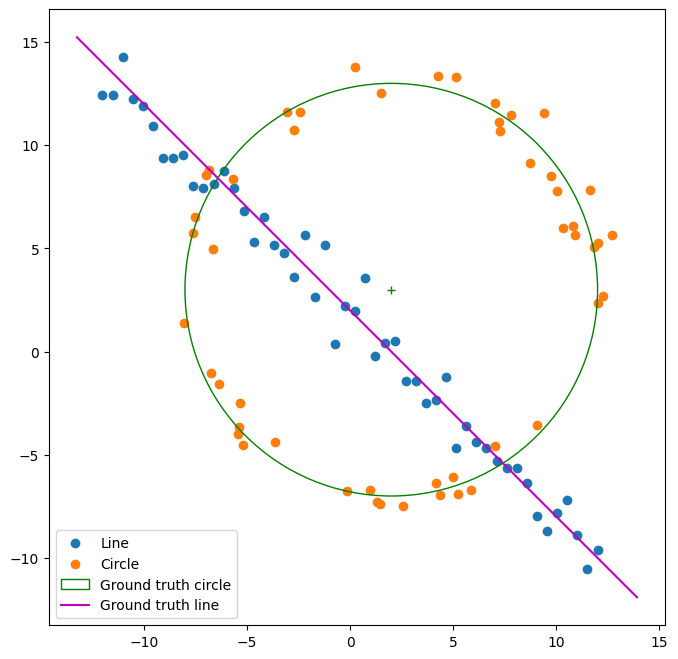

In [45]:
import numpy as np
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt

# np.random.seed(0)
N = 100
half_n = N // 2
r = 10
x0_gt, y0_gt = 2, 3  # Circle center

# Generate noisy circle points
s = r / 16
t = np.random.uniform(0, 2*np.pi, half_n)
n = s * np.random.randn(half_n)
x = x0_gt + (r + n) * np.cos(t)
y = y0_gt + (r + n) * np.sin(t)
X_circ = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

# Generate noisy line points
s = 1.0
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m*x + b + s*np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

# Combine all points
X = np.vstack((X_circ, X_line))

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax.scatter(X_line[:,0], X_line[:,1], label='Line')
ax.scatter(X_circ[:,0], X_circ[:,1], label='Circle')

# Ground truth circle
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground truth circle')
ax.add_patch(circle_gt)
ax.plot(x0_gt, y0_gt, '+', color='g')

# Ground truth line
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m*x_ + b
ax.plot(x_, y_, color='m', label='Ground truth line')

ax.legend()
ax.set_aspect('equal')
plt.show()


**(a)** Estimate the **line** using the **RANSAC algorithm**

In [57]:
import numpy as np

def fit_line_ransac(points, n_iter=1000, threshold=0.5):
    best_inliers = []
    best_params = None
    
    for _ in range(n_iter):
        # Randomly pick 2 points
        idx = np.random.choice(len(points), 2, replace=False)
        p1, p2 = points[idx]
        
        # Compute line parameters [a,b,d] with unit normal
        a = p2[1] - p1[1]
        b = p1[0] - p2[0]
        norm = np.sqrt(a**2 + b**2)
        a, b = a/norm, b/norm
        d = a*p1[0] + b*p1[1]
        
        # Compute perpendicular distances of all points
        distances = np.abs(a*points[:,0] + b*points[:,1] - d)
        inliers = points[distances < threshold]
        
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_params = (a, b, d)
    
    return best_params, best_inliers

# Estimate line on all points
line_params, line_inliers = fit_line_ransac(X, n_iter=1000, threshold=0.5)
print("Estimated line parameters [a, b, d]:", line_params)
print("Number of line inliers:", len(line_inliers))


Estimated line parameters [a, b, d]: (np.float64(-0.6905849305972201), np.float64(-0.7232513073835626), np.float64(-1.1904432919314134))
Number of line inliers: 35


**(b)** Subtract line inliers and fit the circle using RANSAC

In [59]:
def circle_from_3_points(p1, p2, p3):
    A = np.array([
        [p2[0]-p1[0], p2[1]-p1[1]],
        [p3[0]-p1[0], p3[1]-p1[1]]
    ])
    B = np.array([
        [(p2[0]**2 - p1[0]**2 + p2[1]**2 - p1[1]**2)/2],
        [(p3[0]**2 - p1[0]**2 + p3[1]**2 - p1[1]**2)/2]
    ])
    try:
        center = np.linalg.solve(A, B)
        cx, cy = center.flatten()
        r = np.mean(np.sqrt(np.sum((np.array([p1,p2,p3]) - [cx, cy])**2, axis=1)))
        return cx, cy, r
    except np.linalg.LinAlgError:
        return None, None, None

def fit_circle_ransac(points, n_iter=1000, threshold=0.5):
    best_inliers = []
    best_params = None
    
    for _ in range(n_iter):
        idx = np.random.choice(len(points), 3, replace=False)
        p1, p2, p3 = points[idx]
        cx, cy, r = circle_from_3_points(p1, p2, p3)
        if cx is None:
            continue
        
        distances = np.abs(np.sqrt((points[:,0]-cx)**2 + (points[:,1]-cy)**2) - r)
        inliers = points[distances < threshold]
        
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_params = (cx, cy, r, points[idx])
    
    return best_params, best_inliers

# Remove line inliers before fitting circle
remaining_points = np.array([p for p in X if not any(np.all(p==li) for li in line_inliers)])
circle_params, circle_inliers = fit_circle_ransac(remaining_points, n_iter=1000, threshold=0.5)
print("Estimated circle parameters [cx, cy, r]:", circle_params[:3])
print("Number of circle inliers:", len(circle_inliers))


Estimated circle parameters [cx, cy, r]: (np.float64(2.1296613442920274), np.float64(2.7347698110277534), np.float64(9.837911562387207))
Number of circle inliers: 33


**(c)** Plot everything

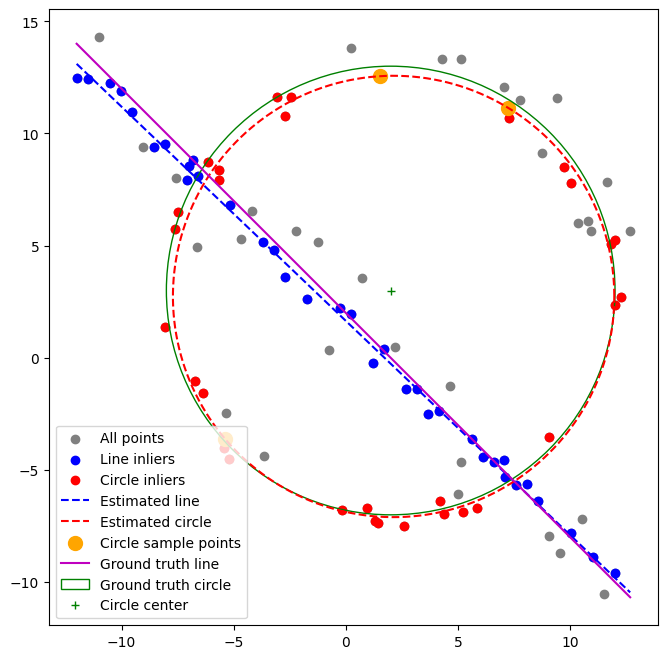

In [60]:
import matplotlib.pyplot as plt

# Ground truth
m, b_gt = -1, 2
x0_gt, y0_gt = 2, 3
r_gt = 10

fig, ax = plt.subplots(1,1,figsize=(8,8))

# All points
ax.scatter(X[:,0], X[:,1], color='gray', label='All points')

# RANSAC inliers
ax.scatter(line_inliers[:,0], line_inliers[:,1], color='blue', label='Line inliers')
ax.scatter(circle_inliers[:,0], circle_inliers[:,1], color='red', label='Circle inliers')

# Estimated line
a, b_line, d = line_params
x_vals = np.array([X[:,0].min(), X[:,0].max()])
y_vals = (d - a*x_vals)/b_line
ax.plot(x_vals, y_vals, 'b--', label='Estimated line')

# Estimated circle
cx, cy, r, sample_points = circle_params
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(cx + r*np.cos(theta), cy + r*np.sin(theta), 'r--', label='Estimated circle')

# Highlight 3 points used for circle
ax.scatter(sample_points[:,0], sample_points[:,1], color='orange', s=100, label='Circle sample points')

# Ground truth line
x_line = np.array([X[:,0].min(), X[:,0].max()])
y_line = m*x_line + b_gt
ax.plot(x_line, y_line, 'm-', label='Ground truth line')

# Ground truth circle
circle_gt = plt.Circle((x0_gt, y0_gt), r_gt, color='g', fill=False, label='Ground truth circle')
ax.add_patch(circle_gt)
ax.plot(x0_gt, y0_gt, '+', color='g', label='Circle center')

ax.set_aspect('equal')
ax.legend()
plt.show()


### (d) What will happen if we fit the circle first?

If we fit the circle first, the RANSAC algorithm may incorrectly include line points as circle inliers, because the line points can be somewhat close to the circle (depending on noise).

This will lead to:

- Poor circle estimation
- Fewer remaining points for line detection, making the line RANSAC less accurate.
